In [23]:
# Install librosa the audio processing library
!pip install librosa --quiet

In [24]:
import os
import warnings
import pickle
import numpy as np
import librosa
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
np.random.seed(42)

In [25]:
# Constants
SAMPLE_RATE      = 16000   
CLIP_DURATION    = 3       
MIN_CYCLE_SECS   = 0.5     
N_MFCC           = 13
N_MELS           = 40
TARGET_PER_CLASS = 1200    
CONFIDENCE_THR   = 0.75
TARGET_LEN       = SAMPLE_RATE * CLIP_DURATION  

In [26]:
# Dataset 1
path1 = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
print("ICBHI path:", path1)

ICBHI path: /kaggle/input/datasets/vbookshelf/respiratory-sound-database


In [27]:
# Dataset 2
path2 = kagglehub.dataset_download("tareqkhanemu/snoring")
print("Snoring path:", path2)

Snoring path: /kaggle/input/datasets/tareqkhanemu/snoring


In [28]:
ICBHI_PATH   = ("/kaggle/input/datasets/vbookshelf/respiratory-sound-database"
                "/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files")
SNORING_PATH = "/kaggle/input/datasets/tareqkhanemu/snoring/Snoring Dataset"

print(f"ICBHI  wav count : {len([f for f in os.listdir(ICBHI_PATH)   if f.endswith('.wav')])}")
snore_folder = os.path.join(SNORING_PATH, '1')
print(f"Snoring clip count : {len([f for f in os.listdir(snore_folder) if f.endswith('.wav')])}")

ICBHI  wav count : 920
Snoring clip count : 500


In [29]:
def extract_features(audio, sr=SAMPLE_RATE):
    """
    Extract a 168-dimensional acoustic feature vector.

    Breakdown
    ---------
    MFCCs            13 x (mean + std) =  26 dims
    Delta-MFCCs      13 x (mean + std) =  26 dims   ← velocity of MFCCs
    Delta²-MFCCs     13 x (mean + std) =  26 dims   ← acceleration of MFCCs
    Mel-spectrogram  40 x (mean + std) =  80 dims   ← fine spectral texture
    ZCR                  (mean + std)  =   2 dims
    Spectral centroid    (mean + std)  =   2 dims
    Spectral rolloff     (mean + std)  =   2 dims
    Spectral bandwidth   (mean + std)  =   2 dims
    RMS energy           (mean + std)  =   2 dims
                                       ─────────
                               TOTAL = 168 dims
    """
    feats = []

    # MFCCs + deltas
    mfcc    = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
    d_mfcc  = librosa.feature.delta(mfcc)
    d2_mfcc = librosa.feature.delta(mfcc, order=2)
    for arr in (mfcc, d_mfcc, d2_mfcc):
        feats += list(np.mean(arr, axis=1)) + list(np.std(arr, axis=1))

    # Mel-spectrogram (in dB)
    mel    = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    feats += list(np.mean(mel_db, axis=1)) + list(np.std(mel_db, axis=1))

    # Spectral / energy descriptors
    for fn in (
        librosa.feature.zero_crossing_rate,
        lambda y, sr: librosa.feature.spectral_centroid(y=y, sr=sr),
        lambda y, sr: librosa.feature.spectral_rolloff(y=y, sr=sr),
        lambda y, sr: librosa.feature.spectral_bandwidth(y=y, sr=sr),
        lambda y, sr: librosa.feature.rms(y=y),
    ):
        try:
            v = fn(y=audio, sr=sr) if 'sr' in fn.__code__.co_varnames else fn(audio)
        except TypeError:
            v = fn(audio)
        feats += [float(np.mean(v)), float(np.std(v))]

    return np.array(feats, dtype=np.float32)

print(f"Feature vector size: {extract_features(np.zeros(TARGET_LEN)).shape[0]} dims")

Feature vector size: 168 dims


In [30]:
def augment_audio(audio, sr=SAMPLE_RATE):
    """
    Returns 4 augmented variants of 'audio', each the same length as the input.

      1. Time-stretch  ±10 %
      2. Pitch-shift   ±2 semitones
      3. Gaussian noise at ~20 dB SNR
      4. Random time-shift ±100 ms (zeros fill the gap)
    """
    n   = len(audio)
    out = []

    # 1 – time stretch
    try:
        rate = float(np.random.uniform(0.9, 1.1))
        ts   = librosa.effects.time_stretch(y=audio, rate=rate)
        ts   = ts[:n] if len(ts) >= n else np.pad(ts, (0, n - len(ts)))
    except Exception:
        ts = audio.copy()
    out.append(ts)

    # 2 – pitch shift
    try:
        ps = librosa.effects.pitch_shift(
            y=audio, sr=sr, n_steps=float(np.random.uniform(-2, 2))
        )
    except Exception:
        ps = audio.copy()
    out.append(ps)

    # 3 – Gaussian noise
    amp   = 0.005 * float(np.max(np.abs(audio)) + 1e-9)
    noisy = audio + (amp * np.random.randn(n)).astype(np.float32)
    out.append(noisy)

    # 4 – time shift
    shift  = int(np.random.uniform(-0.1, 0.1) * sr)
    rolled = np.roll(audio, shift)
    if   shift > 0: rolled[:shift]  = 0
    elif shift < 0: rolled[shift:]  = 0
    out.append(rolled)

    return out

In [31]:
def _pad_or_trim(audio, length=TARGET_LEN):
    if len(audio) >= length:
        return audio[:length]
    return np.pad(audio, (0, length - len(audio)))

In [32]:
def load_icbhi_raw(path):
    """
    Extracts every respiratory cycle from the ICBHI annotation files.

    FIX vs original code
    --------------------
    * 'crackle' is now labelled 'crackle' (NOT 'cough').
      Crackle = discontinuous clicking lung sound heard via stethoscope.
      Cough   = expulsive reflex – a completely different acoustic event.
    * Cycles where BOTH crackle AND wheeze are flagged are SKIPPED.
      Mixing two pathologies into one sample makes class boundaries ambiguous.

    Labels produced: 'normal', 'crackle', 'wheeze'
    """
    data, skipped, errors = [], 0, 0
    wav_files = sorted(f for f in os.listdir(path) if f.endswith('.wav'))
    print(f"ICBHI: {len(wav_files)} recording files – extracting individual cycles …")

    for fname in wav_files:
        wav_path = os.path.join(path, fname)
        txt_path = wav_path.replace('.wav', '.txt')
        if not os.path.exists(txt_path):
            continue
        try:
            audio, _ = librosa.load(wav_path, sr=SAMPLE_RATE)
        except Exception:
            errors += 1
            continue

        with open(txt_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 4:
                    continue
                t0, t1  = float(parts[0]), float(parts[1])
                crackle = int(parts[2])
                wheeze  = int(parts[3])

                if crackle and wheeze:          # skip 'both' class
                    skipped += 1
                    continue
                if (t1 - t0) < MIN_CYCLE_SECS: # skip near-empty cycles
                    skipped += 1
                    continue

                label = 'crackle' if crackle else ('wheeze' if wheeze else 'normal')
                s0, s1 = int(t0 * SAMPLE_RATE), int(t1 * SAMPLE_RATE)
                data.append((_pad_or_trim(audio[s0:s1]), label))

    counts = Counter(lbl for _, lbl in data)
    print(f"crackle: {counts['crackle']:,}  wheeze: {counts['wheeze']:,}  "
          f"normal: {counts['normal']:,}")
    print(f"Skipped {skipped} cycles ('both' + too-short) and Load errors: {errors}")
    return data

In [33]:
def load_snoring_raw(path):
    """
    Loads clips from snoring folder '1'.
    Folder '0' (non-snoring) is intentionally skipped becuase the ICBHI 'normal' class already represents quiet breathing.
    """
    data, errors = [], 0
    folder = os.path.join(path, '1')
    files  = [f for f in os.listdir(folder) if f.endswith('.wav')]
    print(f"  Snoring: {len(files)} clips …")

    for fname in files:
        try:
            audio, _ = librosa.load(
                os.path.join(folder, fname), sr=SAMPLE_RATE, duration=CLIP_DURATION
            )
            data.append((_pad_or_trim(audio), 'snore'))
        except Exception:
            errors += 1

    print(f"Loaded {len(data)} snoring clips and Load errors: {errors}")
    return data

In [34]:
raw_icbhi = load_icbhi_raw(ICBHI_PATH)
raw_snore = load_snoring_raw(SNORING_PATH)
raw_all   = raw_icbhi + raw_snore

counts_raw = Counter(lbl for _, lbl in raw_all)
print(f"\nRaw totals before balancing: {dict(counts_raw)}")
print(f"Grand total: {len(raw_all):,} clips")

ICBHI: 920 recording files – extracting individual cycles …
crackle: 1,861  wheeze: 882  normal: 3,608
Skipped 547 cycles ('both' + too-short) and Load errors: 0
  Snoring: 500 clips …
Loaded 500 snoring clips and Load errors: 0

Raw totals before balancing: {'normal': 3608, 'wheeze': 882, 'crackle': 1861, 'snore': 500}
Grand total: 6,851 clips


In [35]:
def balance_dataset(raw_data, target=TARGET_PER_CLASS, seed=42):
    """
    Makes every class exactly 'target' samples.

    Strategy
    --------
    count >= target  →  randomly subsample to 'target'  (no information added)
    count <  target  →  keep all + audio-level augment until 'target' reached
    """
    rng      = np.random.default_rng(seed)
    by_class = {}
    for audio, lbl in raw_data:
        by_class.setdefault(lbl, []).append(audio)

    bal_audio, bal_labels = [], []

    for cls, clips in sorted(by_class.items()):
        n = len(clips)
        if n >= target:
            chosen = rng.choice(n, size=target, replace=False)
            for i in chosen:
                bal_audio.append(clips[i])
                bal_labels.append(cls)
            print(f"  {cls:10s}: {n:5,d}  →  {target:,}  (downsampled)")
        else:
            for c in clips:
                bal_audio.append(c)
                bal_labels.append(cls)
            needed, idx, added = target - n, 0, 0
            print(f"  {cls:10s}: {n:5,d}  →  {target:,}  (augmenting +{needed}) ", end="", flush=True)
            while added < needed:
                for ac in augment_audio(clips[idx % n]):
                    if added >= needed:
                        break
                    bal_audio.append(ac)
                    bal_labels.append(cls)
                    added += 1
                idx += 1
            print("✓")

    return bal_audio, bal_labels

print(f"Balancing to {TARGET_PER_CLASS:,} samples per class …\n")
bal_audio, bal_labels = balance_dataset(raw_all)
print(f"\nBalanced class counts: {dict(Counter(bal_labels))}")
print(f"Total samples: {len(bal_labels):,}")

Balancing to 1,200 samples per class …

  crackle   : 1,861  →  1,200  (downsampled)
  normal    : 3,608  →  1,200  (downsampled)
  snore     :   500  →  1,200  (augmenting +700) ✓
  wheeze    :   882  →  1,200  (augmenting +318) ✓

Balanced class counts: {'crackle': 1200, 'normal': 1200, 'snore': 1200, 'wheeze': 1200}
Total samples: 4,800


In [36]:
X_all, y_all, errors = [], [], 0
for i, (audio, lbl) in enumerate(zip(bal_audio, bal_labels)):
    if i % 600 == 0:
        print(f"  {i:,} / {len(bal_audio):,}", flush=True)
    try:
        X_all.append(extract_features(audio))
        y_all.append(lbl)
    except Exception:
        errors += 1

X_all = np.array(X_all)
y_all = np.array(y_all)
print(f"\nFeature matrix shape: {X_all.shape}")
print(f"Feature vector dims: {X_all.shape[1]}")
if errors:
    print(f"Skipped {errors} clips due to feature-extraction errors")

  0 / 4,800
  600 / 4,800
  1,200 / 4,800
  1,800 / 4,800
  2,400 / 4,800
  3,000 / 4,800
  3,600 / 4,800
  4,200 / 4,800

Feature matrix shape: (4800, 168)
Feature vector dims: 168


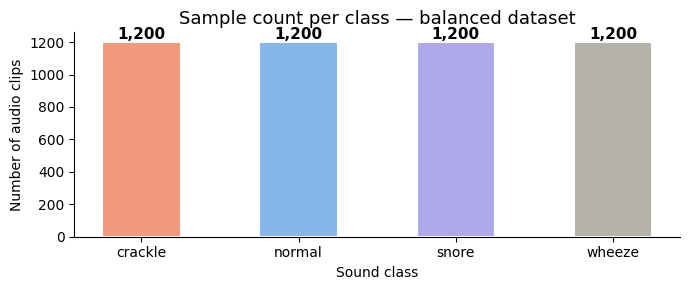

Dataset balanced and ready for training!


In [37]:
classes, counts = np.unique(y_all, return_counts=True)

fig, ax = plt.subplots(figsize=(7, 3))
colors  = ['#F0997B', '#85B7EB', '#AFA9EC', '#B4B2A9']
bars    = ax.bar(classes, counts, color=colors[:len(classes)],
                 width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{cnt:,}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Sample count per class — balanced dataset', fontsize=13)
ax.set_ylabel('Number of audio clips')
ax.set_xlabel('Sound class')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/class_balance.png', dpi=120)
plt.show()
print("Dataset balanced and ready for training!")

In [38]:
# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_all)
print("Label encoding:")
for num, name in enumerate(encoder.classes_):
    print(f"  {num}  →  {name}")

Label encoding:
  0  →  crackle
  1  →  normal
  2  →  snore
  3  →  wheeze


In [39]:
# Normalise features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

In [40]:
# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded,
)
print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")


Training set: 3,840 samples
Test set: 960 samples


In [41]:
model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=25,
    learning_rate_init=0.001,
    batch_size=64,
    verbose=False,
)
model.fit(X_train, y_train)

MLPClassifier(batch_size=64, early_stopping=True,
              hidden_layer_sizes=(256, 128, 64), max_iter=1000,
              n_iter_no_change=25, random_state=42)

In [42]:
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test,  y_test)
print(f"Training accuracy: {train_acc * 100:.1f}%")
print(f"Test accuracy: {test_acc  * 100:.1f}%")

Training accuracy: 95.6%
Test accuracy: 74.3%


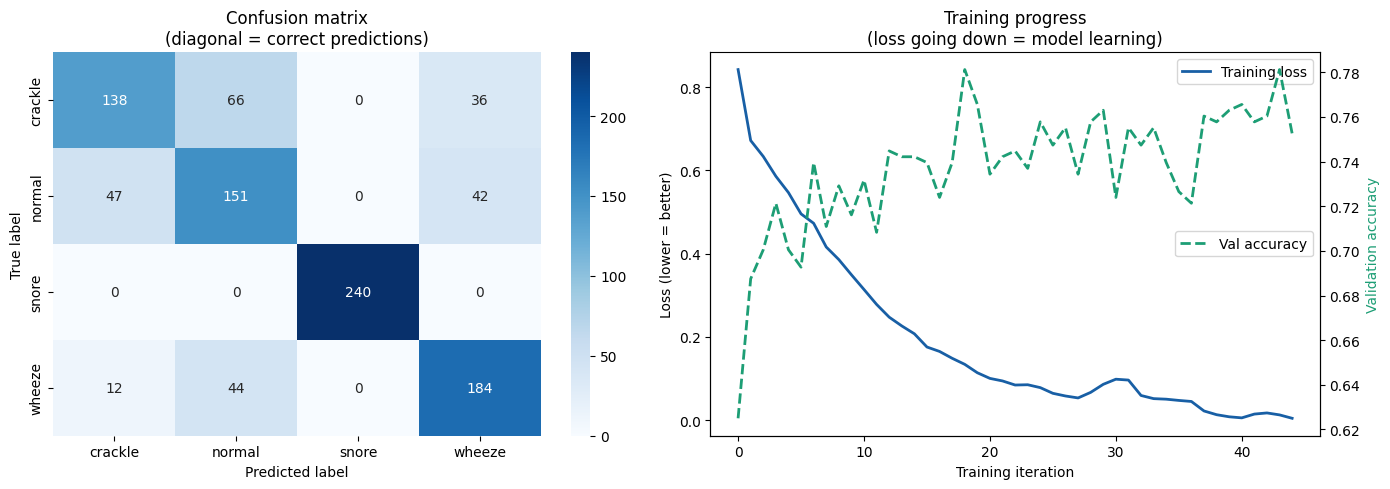

In [43]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            ax=axes[0])
axes[0].set_title('Confusion matrix\n(diagonal = correct predictions)', fontsize=12)
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Training loss + validation accuracy
axes[1].plot(model.loss_curve_, color='#185FA5', linewidth=2, label='Training loss')
if model.validation_scores_:
    ax2 = axes[1].twinx()
    ax2.plot(model.validation_scores_, color='#1D9E75', linewidth=2, linestyle='--', label='Val accuracy')
    ax2.set_ylabel('Validation accuracy', color='#1D9E75')
    ax2.legend(loc='center right')
axes[1].set_title('Training progress\n(loss going down = model learning)', fontsize=12)
axes[1].set_xlabel('Training iteration')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend(loc='upper right')
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/training_results.png', dpi=120)
plt.show()

In [44]:
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

              precision    recall  f1-score   support

     crackle       0.70      0.57      0.63       240
      normal       0.58      0.63      0.60       240
       snore       1.00      1.00      1.00       240
      wheeze       0.70      0.77      0.73       240

    accuracy                           0.74       960
   macro avg       0.75      0.74      0.74       960
weighted avg       0.75      0.74      0.74       960

